In [1]:
import pandas as pd
import sqlite3

## make connection with database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

## gets the datetime from the pageviews table, selecting only users and not the admins

In [3]:
pageviews_users = pd.read_sql(
    '''SELECT datetime
    FROM pageviews
    WHERE uid LIKE 'user_%'
''', conn, parse_dates='datetime'
)
pageviews_users

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


## using pandas, create a new dataframe where the visit are counted and grouped by date

In [4]:
pageviews_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  987 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.8 KB


In [5]:
date_pdageviews_user = pageviews_users.groupby(pageviews_users.datetime.dt.date).count()

In [8]:
date_pdageviews_user.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2020-04-17 to 2020-05-22
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   datetime  33 non-null     int64
dtypes: int64(1)
memory usage: 1.6+ KB


## using pandas method .plot(), create a graph

<Axes: title={'center': 'Views per day'}, xlabel='datetime'>

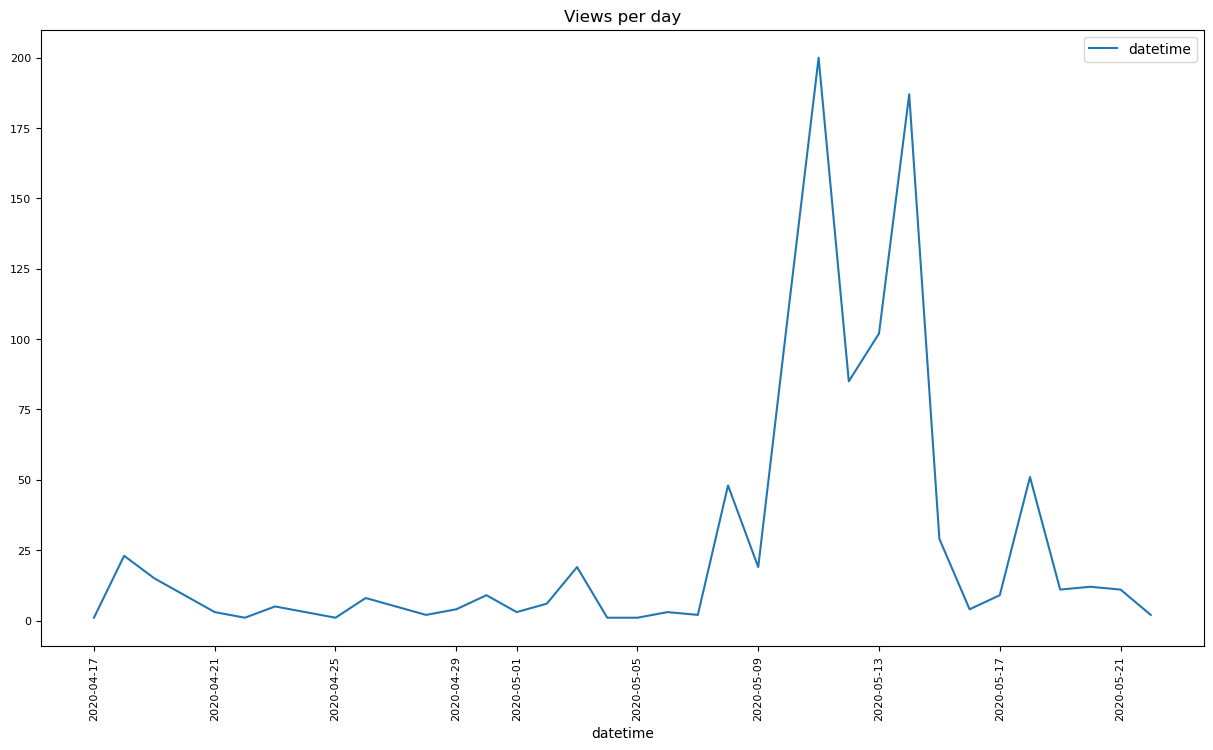

In [6]:
date_pdageviews_user.plot(fontsize=8, figsize=(15,8), title='Views per day', rot=90)

## close the connection to database

In [7]:
conn.close()